In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [53]:
df = pd.read_pickle('iou_estimation.pkl')

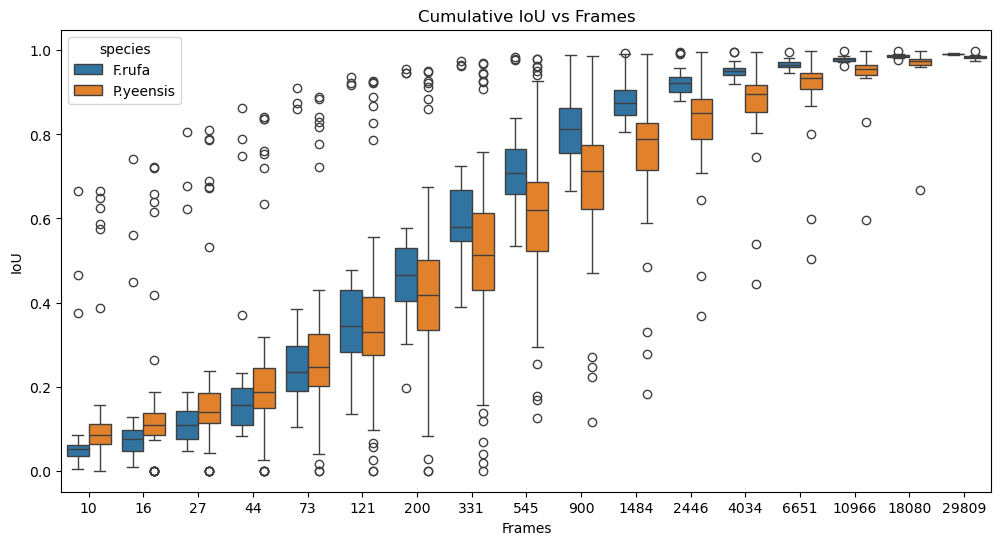

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='length', y='iou', hue='species')
plt.title('Cumulative IoU vs Frames')
plt.xlabel('Frames')
plt.ylabel('IoU')
plt.show()
# plt.savefig('cdf_iou_seaborn.png')

In [ ]:
fig = px.box(df, x='length', y='iou', color='species', log_x=True, boxmode='overlay', height=600, width=1500)
fig.update_layout(
    title='Cumulative IoU vs Frames',  
    xaxis_title='Frames',             
    yaxis_title='IoU',                                    
    legend_title='Species',                           
    font=dict(size=14),                                 
    title_font_size=16
                                   
)

fig.show()
# fig.write_html('cdf_iou.html')

In [83]:
pdf = df.groupby(['species', 'name']).apply(lambda x: pd.Series(np.gradient(x.iou, x.length), x.length)).reset_index()
pdf = pdf.rename(columns={0:'pdf'})

In [ ]:
fig = px.box(pdf, x='length', y='pdf', color='species', boxmode='overlay', log_x=True, height=600, width=1500)
fig.update_layout(
    title='PDF IoU vs Frames',  
    xaxis_title='Frames',             
    yaxis_title='PDF',                                    
    legend_title='Species',                           
    font=dict(size=14),                                 
    title_font_size=16
                                   
)

fig.show()
# fig.write_html('pdf_iou.html')